# Trabalho A2 — Classificação binária (notebook único)

Este notebook segue a mesma sequência do notebook feito em aula (`spam.ipynb`): carregamento, classe
positiva, balanceamento, separação treino/teste, TF-IDF, busca de hiperparâmetros, SHAP e métricas.
Depois vêm as partes que o enunciado pede a mais: comparação de três algoritmos, o programa da Parte 1
(histograma) e os pontos de corte.

**Para trocar de domínio, altere só `BASE_ESCOLHIDA`** na célula de configuração (`"spam"`, `"bank"` ou `"breast"`).

## Instruções de execução (Google Colab)
1. Em [colab.research.google.com](https://colab.research.google.com): **Arquivo → Fazer upload de notebook**.
2. Na célula de configuração, escolha a base em `BASE_ESCOLHIDA`.
3. **Ambiente de execução → Executar tudo**. Se o CSV ainda não estiver no Colab, aparece um botão para enviá-lo.
4. O notebook guarda só a saída da última base executada. Para a entrega, rode uma vez para cada base e salve uma cópia de cada.

Para rodar fora do Colab: `pip install pandas numpy scikit-learn matplotlib shap jupyter`.

In [1]:
# Instala o SHAP (no Colab normalmente já existe; se existir, não faz nada)
%pip install -q shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Configuração — escolha da base

In [2]:
############################################################################
# Cada base do trabalho tem um "cartão" com as informações que o notebook  #
# precisa. Para trocar de domínio, altere apenas BASE_ESCOLHIDA.           #
# Para usar uma base nova, copie um cartão e preencha os campos.           #
############################################################################

BASES = {
    "spam": {
        "caminho": "SMSSpamCollection.csv",     # caminho do arquivo CSV
        "separador": "\t",                      # separador do CSV (tabulação, como na aula)
        "coluna_alvo": "target",                # coluna com a verdade (rótulo)
        "classe_positiva": "spam",              # valor que vira 1 -> pergunta: "a mensagem é spam?"
        "coluna_texto": "text",                 # coluna de texto livre (vira TF-IDF); None se não houver
        "colunas_descartar": [],                # colunas que não podem entrar no modelo
        "terceiro_algoritmo": "Naive Bayes",    # "Naive Bayes", "Gradient Boosting" ou "SVM"
        "tolerancia_t1": 0.03,                  # máx. de spams reais aceitos na faixa negativa automática
        "tolerancia_t2": 0.005,                 # máx. de hams reais aceitos na faixa positiva automática
        "nomes_faixas": ["Negativo automático (entregar)", "Análise manual", "Positivo automático (spam)"],
        "fonte": "UCI Machine Learning Repository — SMS Spam Collection (T. Almeida, J. Hidalgo, 2011). DOI: 10.24432/C5CC84",
        "licenca": "CC BY 4.0",
    },
    "bank": {
        "caminho": "bank.csv",
        "separador": ";",
        "coluna_alvo": "y",
        "classe_positiva": "yes",               # pergunta: "o cliente vai aderir ao depósito a prazo?"
        "coluna_texto": None,
        # 'duration' só é conhecida depois da ligação (vazamento de dados); a documentação
        # original da base (bank-names.txt) recomenda descartá-la num modelo preditivo realista.
        "colunas_descartar": ["duration"],
        "terceiro_algoritmo": "Gradient Boosting",
        "tolerancia_t1": 0.02,
        "tolerancia_t2": 0.05,
        "nomes_faixas": ["Não contatar", "Contato padrão", "Contato prioritário"],
        "fonte": "UCI Machine Learning Repository — Bank Marketing (S. Moro, P. Rita, P. Cortez, 2014). DOI: 10.24432/C5K306. bank.csv = amostra de 10% da base completa",
        "licenca": "CC BY 4.0",
    },
    "breast": {
        "caminho": "breast_cancer_wisconsin.csv",
        "separador": ",",
        "coluna_alvo": "diagnostico",
        "classe_positiva": "M",                 # pergunta: "o tumor é maligno?"
        "coluna_texto": None,
        "colunas_descartar": [],
        "terceiro_algoritmo": "SVM",
        "tolerancia_t1": 0.01,
        "tolerancia_t2": 0.01,
        "nomes_faixas": ["Provável benigno", "Avaliação especializada", "Forte indicação maligna"],
        "fonte": "UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic) (W. Wolberg, O. Mangasarian, N. Street, W. Street, 1995). DOI: 10.24432/C5DW2B",
        "licenca": "CC BY 4.0",
    },
}

BASE_ESCOLHIDA = "bank"      # "spam", "bank" ou "breast"

# Tempo de execução da busca de hiperparâmetros (seção 5):
# False -> configuração da aula (30 combinações, até 700 árvores). Use para os números do relatório.
#          No Colab gratuito leva uns 10 minutos no spam.
# True  -> execução rápida para demonstração (10 combinações, até 200 árvores no Random Forest).
#          Leva 2 a 3 minutos no spam, mas os resultados podem mudar um pouco.
EXECUCAO_RAPIDA = False

config = BASES[BASE_ESCOLHIDA]
print("Base escolhida:", BASE_ESCOLHIDA)
print("Execução rápida:", EXECUCAO_RAPIDA)

Base escolhida: bank
Execução rápida: False


## 1. Carregamento dos dados e definição da classe positiva

In [3]:
import os
import pandas as pd

caminho = config["caminho"]

# No Google Colab: se o arquivo ainda não estiver no ambiente, abre o botão
# para enviar o CSV do computador.
if not os.path.exists(caminho):
    from google.colab import files
    arquivos_enviados = files.upload()
    caminho = list(arquivos_enviados.keys())[0]

df = pd.read_csv(caminho, sep=config["separador"])

# Remove linhas com valores faltantes (as três bases do trabalho não têm nenhuma).
linhas_antes = len(df)
df = df.dropna()

print(f"Linhas: {len(df)} (removidas por valores faltantes: {linhas_antes - len(df)})")
print("Fonte:  ", config["fonte"])
print("Licença:", config["licenca"])
df.head()

Linhas: 4521 (removidas por valores faltantes: 0)
Fonte:   UCI Machine Learning Repository — Bank Marketing (S. Moro, P. Rita, P. Cortez, 2014). DOI: 10.24432/C5K306. bank.csv = amostra de 10% da base completa
Licença: CC BY 4.0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
coluna_alvo = config["coluna_alvo"]
classe_positiva = config["classe_positiva"]

# Mesma ideia da aula (spam = 1, ham = 0): a classe positiva vira 1 e a outra vira 0.
# A nova coluna se chama 'alvo' para não sobrescrever a coluna original.
df['alvo'] = df[coluna_alvo].apply(lambda x: 1 if str(x) == str(classe_positiva) else 0)

print(f"Variável-alvo: '{coluna_alvo}' | classe positiva: '{classe_positiva}' -> 1")
df[[coluna_alvo, 'alvo']].drop_duplicates()

Variável-alvo: 'y' | classe positiva: 'yes' -> 1


,y,alvo
0,no,0
13,yes,1


## 2. Verificação do balanceamento (item iii)

In [5]:
############################################
#Verificação do percentual de balancamento:#
#(i) Fazer agrupamento pelo alvo           #
#(ii) Contar o total do agrupamento.       #
#(iii) Cálculo da porcentagem.             #
############################################

contagem_classes = df.groupby('alvo')['alvo'].count()

total = contagem_classes.sum()

porcentagem_classes = contagem_classes / total * 100
print(contagem_classes)
print()
print(porcentagem_classes)

# Referência para a discussão da métrica: a acurácia de um modelo que sempre
# "chuta" a classe majoritária, sem aprender nada.
print(f"\nAcurácia de quem sempre prevê a classe majoritária: {porcentagem_classes.max():.2f}%")

alvo
0    4000
1     521
Name: alvo, dtype: int64

alvo
0    88.476001
1    11.523999
Name: alvo, dtype: float64

Acurácia de quem sempre prevê a classe majoritária: 88.48%


> **Para o relatório:** discutir como o balanceamento e o custo de cada tipo de erro no domínio
> justificam usar o F1 (e não a acurácia) como métrica principal.

## 3. Separação treino/teste (item iv)

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
# X representação do feature space (espaço de características): todas as colunas,
# menos o rótulo original, a coluna 'alvo' e as colunas descartadas
X = df.drop(columns=[coluna_alvo, 'alvo'] + config["colunas_descartar"])
# y representação do target (a verdade - a base é supervisionada)
y = df['alvo']
# O método train_test_split recebe de parâmetro:
#(i) X -> Espaço de características
#(ii) y-> target (a verdade)
#(iii) test_size -> porcentagem que será separada para teste, no caso 25% de todas as instâncias
#(iv) random_state -> é a seed (semente) para a geração do sorteio das instâncias
#(v) stratify -> (adicionado em relação à aula) mantém a mesma proporção de positivos
#    no treino e no teste, importante quando a classe positiva é minoritária
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
# O método train_test_split retorna 4 variáveis:
#(i) X_train -> espaço de características de treinamento (75% da base)
#(ii) X_test -> espaço de características de teste (25% da base)
#(iii) y_train -> target de treinamento
#(iv) y_test ->  target de teste
# O teste fica guardado até a avaliação final. A validação é feita por validação
# cruzada dentro do treino (seção 5).

print("Treino:", X_train.shape[0], " Teste:", X_test.shape[0])
print("Proporção da classe positiva no treino:", round(y_train.mean(), 4), " no teste:", round(y_test.mean(), 4))

ImportError: DLL load failed while importing _matching: Uma política de Controle de Aplicativo bloqueou este arquivo.

## 4. Pré-processamento e representação (item v)
- **Texto** (spam): TF-IDF com os mesmos parâmetros da aula.
- **Tabular** (bank e breast): One-Hot Encoding nas colunas categóricas e padronização nas numéricas.

**Diferença importante em relação à aula:** na aula, o `vectorizer.fit_transform(X_train)` era feito
**antes** da validação cruzada. Assim, o vocabulário e os pesos IDF já tinham visto as mensagens dos folds de
validação. O enunciado pede o contrário, no item (v): ajustar as transformações "inclusive dentro de cada
divisão da validação cruzada". Por isso, aqui o pré-processamento é só **definido** nesta seção e entra num
`Pipeline` na seção 5. Assim, ele é reajustado em cada fold usando apenas os dados de treino daquele fold.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

coluna_texto = config["coluna_texto"]

if coluna_texto is not None:
    # Base de texto: TF-IDF com os mesmos parâmetros usados em aula
    preprocessador = ColumnTransformer(transformers=[
        ("tfidf",
         TfidfVectorizer(
             token_pattern=r"\b[A-Za-zÀ-ÿ]+\b",
             max_features=500,
             ngram_range=(1, 2),
             use_idf=True
         ),
         coluna_texto)
    ])
    print("Representação: TF-IDF da coluna", coluna_texto)
else:
    # Base tabular: separa as colunas numéricas das categóricas (texto curto, ex.: 'job', 'month')
    colunas_numericas = X_train.select_dtypes(include="number").columns.tolist()
    colunas_categoricas = X_train.select_dtypes(exclude="number").columns.tolist()

    preprocessador = ColumnTransformer(transformers=[
        # One-Hot: cada categoria vira uma coluna 0/1; categorias novas no teste são ignoradas
        ("onehot", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas),
        # Padronização: média 0 e desvio 1 (importante para Regressão Logística e SVM)
        ("padronizacao", StandardScaler(), colunas_numericas)
    ])
    print("Categóricas (One-Hot):", colunas_categoricas)
    print("Numéricas (padronização):", colunas_numericas)

Representação: TF-IDF da coluna text


In [ ]:
# Apenas para VISUALIZAR a representação, como na aula (X_train_tfidf_df).
# Este ajuste não é usado no treinamento: lá o Pipeline refaz o ajuste dentro de cada fold.
from sklearn.base import clone

preprocessador_visualizacao = clone(preprocessador)
X_train_transformado = preprocessador_visualizacao.fit_transform(X_train)

# Nomes das colunas geradas (ex.: 'tfidf__free' vira 'free')
palavras = [nome.split("__")[-1] for nome in preprocessador_visualizacao.get_feature_names_out()]

# TF-IDF e One-Hot geram matriz esparsa (quase tudo zero); toarray() converte para visualizar
if hasattr(X_train_transformado, "toarray"):
    X_train_transformado = X_train_transformado.toarray()

X_train_transformado_df = pd.DataFrame(
    X_train_transformado,
    index=X_train.index,
    columns=palavras
)

print("Shape treino transformado:", X_train_transformado_df.shape)
X_train_transformado_df

Shape treino transformado: (4179, 500)


,a,a bit,a good,a great,about,account,actually,after,again,all,...,you have,you i,you in,you know,you re,you want,your,your mobile,yup,ü
4747,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.000000
5295,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.000000
5568,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.398253
4654,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.2674,0.0,0.0,0.000000
1133,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329,0.000000,0.0,0.0,0.0,0.42982,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.000000
1932,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.000000
5316,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.000000
3217,0.097073,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.187709,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.000000


In [ ]:
# A tabela acima parece ter "só zeros" porque o pandas mostra apenas as primeiras e as
# últimas linhas e colunas, e cada mensagem usa poucas das 500 palavras do vocabulário.
# Esta célula mostra onde estão os valores diferentes de zero.

# (i) Quantas células da matriz têm valor diferente de zero
celulas_preenchidas = (X_train_transformado != 0).sum()
print(f"Células diferentes de zero: {celulas_preenchidas} de {X_train_transformado.size} "
      f"({celulas_preenchidas / X_train_transformado.size:.2%})")

# (ii) Para as 3 primeiras linhas do treino, os atributos com valor diferente de zero
for indice in X_train_transformado_df.index[:3]:
    valores = X_train_transformado_df.loc[indice]
    valores = valores[valores != 0]
    valores = valores.reindex(valores.abs().sort_values(ascending=False).index).head(10)
    print(f"\nLinha {indice}:")
    if coluna_texto is not None:
        print("  Mensagem:", X_train.loc[indice, coluna_texto])
    print("  Valores diferentes de zero:", valores.round(3).to_dict())

Células diferentes de zero: 45609 de 2089500 (2.18%)

Linha 4747:
  Mensagem: Orh i tot u say she now still dun believe.
  Valores diferentes de zero: {'dun': 0.506, 'say': 0.451, 'she': 0.439, 'still': 0.404, 'now': 0.301, 'u': 0.253, 'i': 0.174}

Linha 5295:
  Mensagem: Alex says he's not ok with you not being ok with it
  Valores diferentes de zero: {'ok': 0.506, 'with': 0.475, 'not': 0.454, 'being': 0.358, 'he': 0.28, 's': 0.211, 'it': 0.202, 'you': 0.141}

Linha 5568:
  Mensagem: Will ü b going to esplanade fr home?
  Valores diferentes de zero: {'going to': 0.462, 'b': 0.437, 'ü': 0.398, 'going': 0.389, 'home': 0.384, 'will': 0.321, 'to': 0.187}


## 5. Comparação de três algoritmos e busca de hiperparâmetros (item vi)
Mesma busca da aula (`RandomizedSearchCV` + `StratifiedKFold`, otimizando F1), repetida para três algoritmos:
Random Forest (o da aula), Regressão Logística e um terceiro que depende da base (Naive Bayes para texto,
Gradient Boosting para o bank, SVM para o breast). O melhor modelo é o de maior F1 médio na validação cruzada,
sem usar o teste.

Como o modelo agora está dentro de um `Pipeline` (`prep` + `clf`), os nomes dos hiperparâmetros ganham o
prefixo `clf__`, que indica que o parâmetro é do classificador.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# Validação cruzada estratificada (igual à aula)
validacao = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelos e valores que serão testados
modelos_candidatos = {
    # Random Forest com a mesma grade usada em aula
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=1),   # n_jobs=1 evita paralelismo duplicado
        {
            "clf__n_estimators": [200, 300, 500, 700],
            "clf__max_depth": [None, 10, 20, 30, 50],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 4],
            "clf__max_features": ["sqrt", "log2", 0.3, 0.5],
            "clf__class_weight": [None, "balanced", "balanced_subsample"],
            "clf__criterion": ["gini", "entropy"]
        }
    ),
    # Regressão Logística: modelo linear; C controla a regularização (menor C = modelo mais contido)
    "Regressão Logística": (
        LogisticRegression(max_iter=3000, random_state=42),
        {
            "clf__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
            "clf__solver": ["liblinear", "lbfgs"],
            "clf__class_weight": [None, "balanced"]
        }
    ),
}

# Terceiro algoritmo, escolhido no cartão da base
if config["terceiro_algoritmo"] == "Naive Bayes":
    # Feito para contagens/frequências de palavras (só serve para texto)
    modelos_candidatos["Naive Bayes"] = (
        MultinomialNB(),
        {
            "clf__alpha": [0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1, 2, 5, 10],
            "clf__fit_prior": [True, False]
        }
    )
elif config["terceiro_algoritmo"] == "Gradient Boosting":
    # Árvores treinadas em sequência, cada uma corrigindo os erros da anterior
    modelos_candidatos["Gradient Boosting"] = (
        GradientBoostingClassifier(random_state=42),
        {
            "clf__n_estimators": [100, 200, 300],
            "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "clf__max_depth": [2, 3, 4, 5],
            "clf__subsample": [0.7, 0.85, 1.0],
            "clf__min_samples_leaf": [1, 5, 10]
        }
    )
elif config["terceiro_algoritmo"] == "SVM":
    # SVM com kernel RBF; probability=True para ter predict_proba
    modelos_candidatos["SVM"] = (
        SVC(kernel="rbf", probability=True, random_state=42),
        {
            "clf__C": [0.1, 0.5, 1, 5, 10, 50, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
            "clf__class_weight": [None, "balanced"]
        }
    )

# Execução rápida: menos combinações e florestas menores (só para demonstração)
if EXECUCAO_RAPIDA:
    quantidade_combinacoes = 10
    modelos_candidatos["Random Forest"][1]["clf__n_estimators"] = [100, 200]
else:
    quantidade_combinacoes = 30     # mesma configuração da aula

resultados = {}

for nome, (modelo_base, parametros) in modelos_candidatos.items():
    print(f"\n===== {nome} =====")

    # Pipeline: pré-processamento + classificador. Dentro da validação cruzada,
    # o pré-processamento é reajustado em cada fold, só com os dados de treino do fold.
    pipeline = Pipeline([
        ("prep", preprocessador),
        ("clf", modelo_base)
    ])

    # Busca aleatória dos melhores hiperparâmetros (mesma configuração da aula)
    busca = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=parametros,
        n_iter=quantidade_combinacoes,
        scoring="f1",       # classe positiva = 1
        cv=validacao,
        refit=True,
        n_jobs=-1,          # utiliza todos os núcleos disponíveis
        verbose=1,          # na aula era 2; 1 mostra só o resumo de cada busca
        random_state=42,
        error_score="raise"
    )

    # Realizando a busca somente com os dados de treinamento
    busca.fit(X_train, y_train)

    resultados[nome] = {
        "melhor_modelo": busca.best_estimator_,   # já retorna treinado no treino completo
        "melhores_parametros": busca.best_params_,
        "f1_validacao": busca.best_score_,
        "desvio_validacao": busca.cv_results_["std_test_score"][busca.best_index_]
    }

    print("Melhores hiperparâmetros:", busca.best_params_)
    print(f"Melhor F1 médio na validação: {busca.best_score_:.4f}")


===== Random Forest =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores hiperparâmetros: {'clf__n_estimators': 700, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 50, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}
Melhor F1 médio na validação: 0.9320

===== Regressão Logística =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores hiperparâmetros: {'clf__solver': 'lbfgs', 'clf__class_weight': None, 'clf__C': 50}
Melhor F1 médio na validação: 0.9289

===== Naive Bayes =====
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\python\avaliacao-a2.1\.venv\Lib\site-packages\sklearn\model_selection\_search.py:327: UserWarning: The total space of parameters 20 is smaller than n_iter=30. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Melhores hiperparâmetros: {'clf__fit_prior': True, 'clf__alpha': 0.05}
Melhor F1 médio na validação: 0.8960


In [ ]:
# Tabela comparativa da validação cruzada
tabela_validacao = pd.DataFrame([
    {
        "Algoritmo": nome,
        "F1 médio (validação)": round(r["f1_validacao"], 4),
        "Desvio (validação)": round(r["desvio_validacao"], 4),
        "Melhores hiperparâmetros": r["melhores_parametros"]
    }
    for nome, r in resultados.items()
]).sort_values("F1 médio (validação)", ascending=False).reset_index(drop=True)

# O melhor modelo é o de maior F1 médio na validação (o teste não participa da escolha)
melhor_nome = tabela_validacao.loc[0, "Algoritmo"]
melhor_modelo = resultados[melhor_nome]["melhor_modelo"]

print("MELHOR MODELO:", melhor_nome)
print("\nMelhores hiperparâmetros:")
print(resultados[melhor_nome]["melhores_parametros"])
print(f"\nMelhor F1 médio na validação: {resultados[melhor_nome]['f1_validacao']:.4f}")
tabela_validacao

MELHOR MODELO: Random Forest

Melhores hiperparâmetros:
{'clf__n_estimators': 700, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 50, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}

Melhor F1 médio na validação: 0.9320


,Algoritmo,F1 médio (validação),Desvio (validação),Melhores hiperparâmetros
0,Random Forest,0.9320,0.0176,"{'clf__n_estimators': 700, 'clf__min_samples_s..."
1,Regressão Logística,0.9289,0.0147,"{'clf__solver': 'lbfgs', 'clf__class_weight': ..."
2,Naive Bayes,0.8960,0.0155,"{'clf__fit_prior': True, 'clf__alpha': 0.05}"


## 6. SHAP — explicação do melhor modelo (item viii)
Mesmo procedimento da aula: uma amostra de até 200 instâncias do **conjunto de teste** e o gráfico beeswarm
(`plot_type="dot"`). O explicador depende do tipo de modelo:
- Random Forest e Gradient Boosting: `TreeExplainer`, como na aula.
- Regressão Logística: `LinearExplainer`.
- Naive Bayes e SVM: explicador por permutação, que funciona com qualquer modelo mas é mais lento
  (por isso usa 100 instâncias).

A célula imprime **qual saída está sendo explicada** e **quais dados foram usados**, como o item (viii) exige.

Modelo explicado: Random Forest
Saída explicada:  probabilidade da classe positiva ('spam')
Dados usados:     200 instâncias sorteadas do conjunto de TESTE (semente 42)


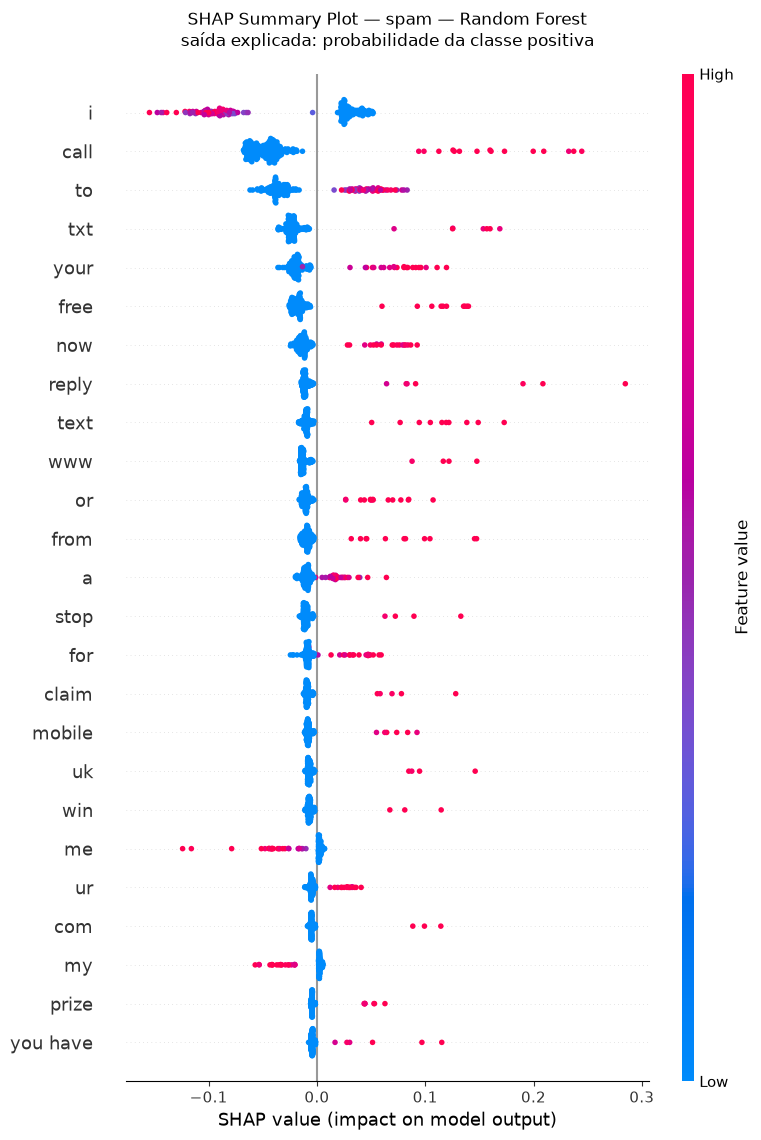

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# O SHAP trabalha com o classificador e com os dados JÁ transformados
# (TF-IDF ou One-Hot/padronização), então separamos as duas partes do Pipeline.
preprocessador_treinado = melhor_modelo.named_steps["prep"]
classificador = melhor_modelo.named_steps["clf"]

X_test_transformado = preprocessador_treinado.transform(X_test)
X_train_transformado = preprocessador_treinado.transform(X_train)

# Recupera os nomes dos atributos (palavras, categorias ou colunas numéricas)
nomes_atributos = [nome.split("__")[-1] for nome in preprocessador_treinado.get_feature_names_out()]

# Localiza a posição da classe positiva 1
indice_classe_positiva = list(classificador.classes_).index(1)

eh_arvore = isinstance(classificador, (RandomForestClassifier, GradientBoostingClassifier))
eh_linear = isinstance(classificador, LogisticRegression)

# O cálculo do SHAP pode ser demorado. Por isso, usamos uma amostra aleatória do teste.
quantidade_amostras = min(200 if (eh_arvore or eh_linear) else 100, X_test_transformado.shape[0])

gerador = np.random.default_rng(42)

indices_shap = gerador.choice(
    X_test_transformado.shape[0],
    size=quantidade_amostras,
    replace=False
)

# Seleciona as instâncias sorteadas e converte para matriz densa
X_shap_matriz = X_test_transformado[indices_shap]
X_shap_array = X_shap_matriz.toarray() if hasattr(X_shap_matriz, "toarray") else np.asarray(X_shap_matriz)

# Cria um DataFrame para que os nomes apareçam no gráfico
X_shap = pd.DataFrame(
    X_shap_array,
    columns=nomes_atributos
)

if eh_arvore:
    # Explicador específico para modelos baseados em árvores (igual à aula)
    explainer = shap.TreeExplainer(classificador)
    valores_shap = explainer(X_shap, check_additivity=False)
    saida_explicada = ("probabilidade da classe positiva" if isinstance(classificador, RandomForestClassifier)
                       else "log-odds (margem) da classe positiva")
elif eh_linear:
    # Explicador para modelos lineares; usa 200 instâncias do treino como referência
    fundo = X_train_transformado[gerador.choice(X_train_transformado.shape[0], size=min(200, X_train_transformado.shape[0]), replace=False)]
    fundo = fundo.toarray() if hasattr(fundo, "toarray") else np.asarray(fundo)
    explainer = shap.LinearExplainer(classificador, fundo)
    valores_shap = explainer(X_shap_array)
    saida_explicada = "log-odds (margem) da classe positiva"
else:
    # Explicador por permutação: serve para qualquer modelo que tenha predict_proba
    fundo = X_train_transformado[gerador.choice(X_train_transformado.shape[0], size=min(50, X_train_transformado.shape[0]), replace=False)]
    fundo = fundo.toarray() if hasattr(fundo, "toarray") else np.asarray(fundo)
    funcao_probabilidade = lambda matriz: classificador.predict_proba(matriz)[:, indice_classe_positiva]
    explainer = shap.Explainer(funcao_probabilidade, shap.maskers.Independent(fundo, max_samples=len(fundo)),
                               algorithm="permutation", seed=42)
    valores_shap = explainer(X_shap_array, max_evals=2 * X_shap_array.shape[1] + 1)
    saida_explicada = "probabilidade da classe positiva"

# Em classificações binárias, o SHAP pode produzir uma dimensão
# separada para cada classe. Selecionamos somente a classe positiva.
if valores_shap.values.ndim == 3:
    valores_positiva = valores_shap.values[:, :, indice_classe_positiva]
else:
    valores_positiva = valores_shap.values

print("Modelo explicado:", melhor_nome)
print("Saída explicada: ", saida_explicada, f"('{classe_positiva}')")
print("Dados usados:    ", quantidade_amostras, "instâncias sorteadas do conjunto de TESTE (semente 42)")

# Cria o SHAP Summary Plot (beeswarm)
shap.summary_plot(
    valores_positiva,
    X_shap,
    feature_names=nomes_atributos,
    plot_type="dot",
    max_display=25,
    show=False
)

plt.title(
    f"SHAP Summary Plot — {BASE_ESCOLHIDA} — {melhor_nome}\nsaída explicada: {saida_explicada}",
    pad=20
)

plt.tight_layout()
plt.show()

> **Para o relatório:** identificar as características mais relevantes e explicar como valores altos
> (vermelho) e baixos (azul) aumentam ou diminuem a saída explicada.

## 7. Avaliação do melhor modelo no conjunto de teste (item vii)
Mesmo código e mesmos gráficos da aula (matriz de confusão, ROC, Precision-Recall e barras das métricas).
Há dois acréscimos pedidos pelo enunciado:
- **Limiar informado:** as métricas de decisão (acurácia, precisão, recall, F1 e matriz de confusão) usam
  **limiar 0,50** aplicado explicitamente sobre a probabilidade (`y_prob >= 0.5`). Na aula foi usado
  `predict()`; o resultado é o mesmo para o Random Forest, mas no SVM o `predict()` usa outra regra e
  pode discordar da probabilidade.
- **Average Precision (AP)** aparece separada da AUC-PR trapezoidal.

**Como as curvas são construídas:** o limiar varia de 1 até 0. Em cada valor, as instâncias com
probabilidade acima dele são classificadas como positivas.
- **ROC:** taxa de falsos positivos, FP/(FP+TN), no eixo X, e taxa de verdadeiros positivos (recall),
  TP/(TP+FN), no eixo Y. A AUC-ROC é a área sob essa curva: 0,5 é aleatório, 1,0 é separação perfeita.
- **Precision-Recall:** recall no eixo X e precisão, TP/(TP+FP), no eixo Y. A referência é a proporção de
  positivos. Em bases desbalanceadas ela é mais exigente que a ROC.
- **AUC-PR (trapezoidal):** `auc(recall, precisão)`, soma de trapézios entre os pontos da curva.
- **Average Precision (AP):** `average_precision_score`, soma de (R<sub>n</sub> − R<sub>n−1</sub>) × P<sub>n</sub>,
  a precisão em cada limiar ponderada pelo ganho de recall, sem interpolação.

Métricas do conjunto de teste — Random Forest (limiar 0.50):


,Métrica,Valor
0,Acurácia,0.9792
1,Precisão,0.9389
2,Recall,0.9037
3,F1-score,0.9210
4,ROC-AUC,0.9891
5,AUC-PR (trapezoidal),0.9691
6,Average Precision (AP),0.9691


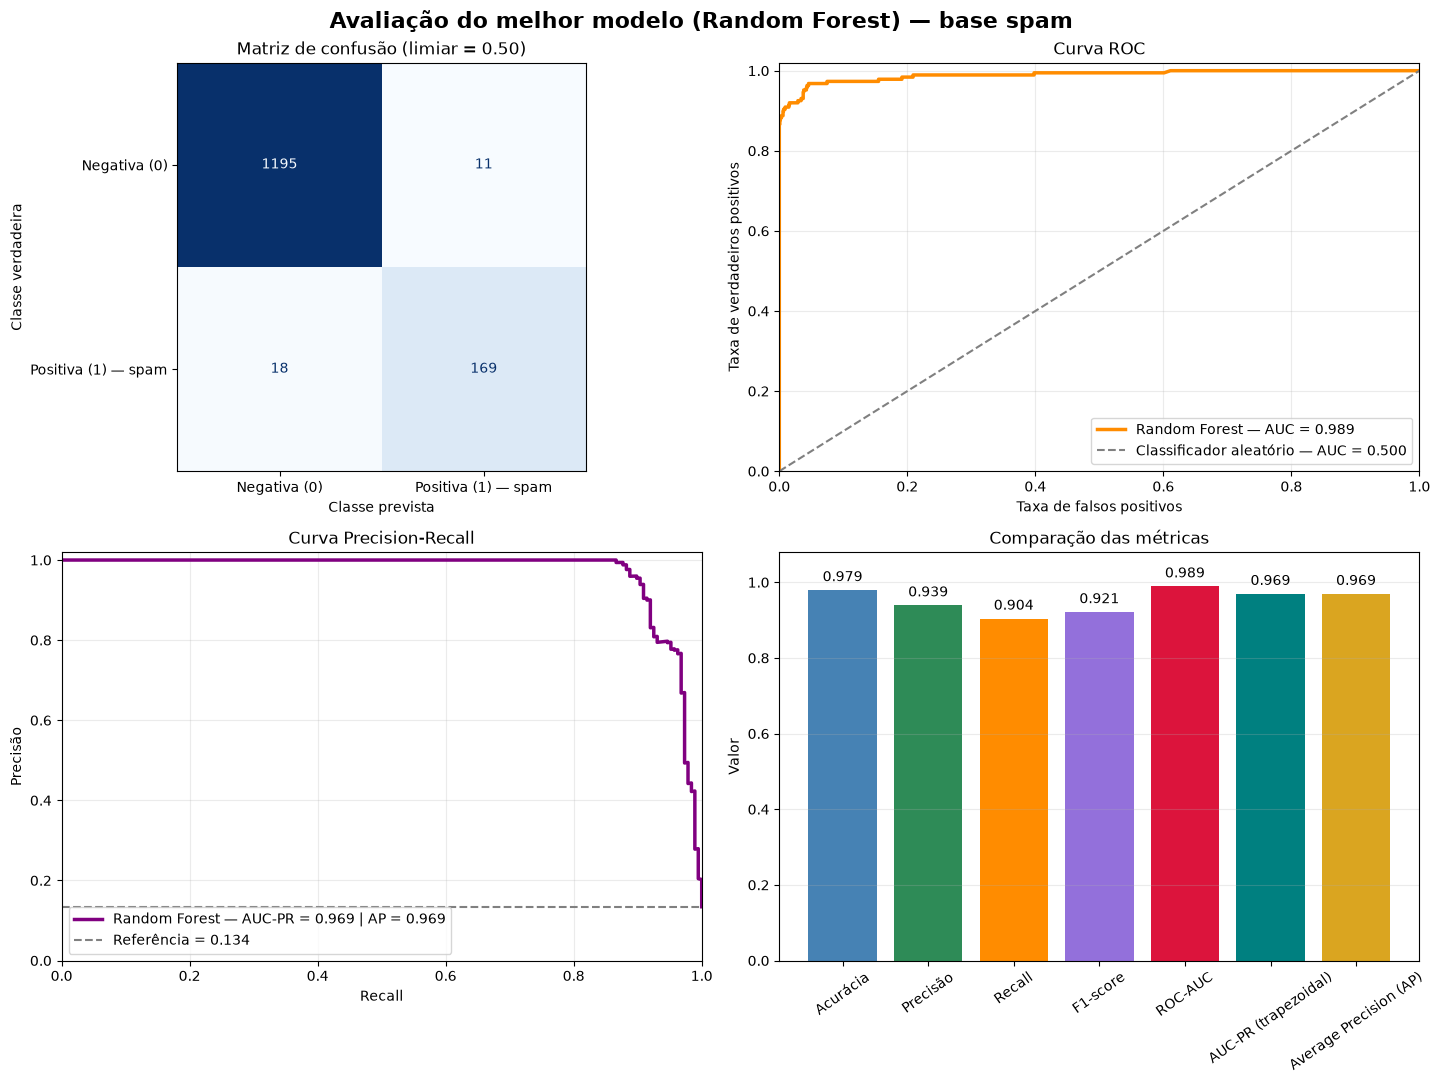

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    ConfusionMatrixDisplay
)

# ---------------------------------------------------------
# 1. Realizando as previsões
# ---------------------------------------------------------

# Descobre em qual coluna do predict_proba está a classe positiva (classe 1).
indice_positiva = list(melhor_modelo.classes_).index(1)

# Probabilidade de cada instância pertencer à classe positiva.
# As probabilidades são necessárias para calcular ROC-AUC e AUC-PR.
y_prob = melhor_modelo.predict_proba(X_test)[:, indice_positiva]

# Classes previstas usando o limiar de 0,50 sobre a probabilidade.
limiar = 0.50
y_pred = (y_prob >= limiar).astype(int)


# ---------------------------------------------------------
# 2. Calculando as métricas
# ---------------------------------------------------------

acuracia = accuracy_score(y_test, y_pred)

# pos_label=1 informa que 1 é a classe positiva.
precisao = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

revocacao = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

# Área sob a curva ROC.
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# Pontos usados para construir a curva Precision-Recall.
precisoes_curva, revocacoes_curva, limiares_pr = precision_recall_curve(
    y_test,
    y_prob,
    pos_label=1
)

# Área sob a curva Precision-Recall usando integração trapezoidal.
auc_pr = auc(
    revocacoes_curva,
    precisoes_curva
)

# Average Precision: outra forma de resumir a curva PR (sem interpolação).
ap = average_precision_score(
    y_test,
    y_prob,
    pos_label=1
)

metricas = pd.DataFrame({
    "Métrica": [
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "AUC-PR (trapezoidal)",
        "Average Precision (AP)"
    ],
    "Valor": [
        acuracia,
        precisao,
        revocacao,
        f1,
        roc_auc,
        auc_pr,
        ap
    ]
})

print(f"Métricas do conjunto de teste — {melhor_nome} (limiar {limiar:.2f}):")
display(
    metricas.style.format({"Valor": "{:.4f}"})
)


# ---------------------------------------------------------
# 3. Preparando as curvas
# ---------------------------------------------------------

fpr, tpr, limiares_roc = roc_curve(
    y_test,
    y_prob,
    pos_label=1
)

# Proporção da classe positiva no teste.
# Representa a linha de referência da curva Precision-Recall.
proporcao_positiva = np.mean(np.asarray(y_test) == 1)


# ---------------------------------------------------------
# 4. Desenhando os gráficos
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 11)
)

# Gráfico 1: matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[0, 1],
    display_labels=["Negativa (0)", f"Positiva (1) — {classe_positiva}"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title(f"Matriz de confusão (limiar = {limiar:.2f})")
axes[0, 0].set_xlabel("Classe prevista")
axes[0, 0].set_ylabel("Classe verdadeira")


# Gráfico 2: curva ROC
axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2.5,
    color="darkorange",
    label=f"{melhor_nome} — AUC = {roc_auc:.3f}"
)

axes[0, 1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Classificador aleatório — AUC = 0.500"
)

axes[0, 1].set_title("Curva ROC")
axes[0, 1].set_xlabel("Taxa de falsos positivos")
axes[0, 1].set_ylabel("Taxa de verdadeiros positivos")
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1.02)
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend(loc="lower right")


# Gráfico 3: curva Precision-Recall
axes[1, 0].plot(
    revocacoes_curva,
    precisoes_curva,
    linewidth=2.5,
    color="purple",
    label=f"{melhor_nome} — AUC-PR = {auc_pr:.3f} | AP = {ap:.3f}"
)

axes[1, 0].axhline(
    proporcao_positiva,
    linestyle="--",
    color="gray",
    label=f"Referência = {proporcao_positiva:.3f}"
)

axes[1, 0].set_title("Curva Precision-Recall")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precisão")
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(loc="lower left")


# Gráfico 4: comparação das métricas
cores = [
    "steelblue",
    "seagreen",
    "darkorange",
    "mediumpurple",
    "crimson",
    "teal",
    "goldenrod"
]

barras = axes[1, 1].bar(
    metricas["Métrica"],
    metricas["Valor"],
    color=cores
)

axes[1, 1].set_title("Comparação das métricas")
axes[1, 1].set_ylabel("Valor")
axes[1, 1].set_ylim(0, 1.08)
axes[1, 1].tick_params(axis="x", rotation=35)
axes[1, 1].grid(axis="y", alpha=0.25)

# Escreve o valor acima de cada barra.
for barra, valor in zip(barras, metricas["Valor"]):
    axes[1, 1].text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.015,
        f"{valor:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.suptitle(
    f"Avaliação do melhor modelo ({melhor_nome}) — base {BASE_ESCOLHIDA}",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

,Melhor na validação,Acurácia,Precisão,Recall,F1-score,ROC-AUC,AUC-PR (trapezoidal),Average Precision (AP)
Algoritmo,,,,,,,,
Random Forest,sim,0.9792,0.9389,0.9037,0.9210,0.9891,0.9691,0.9691
Regressão Logística,,0.9864,0.9941,0.9037,0.9468,0.9843,0.9624,0.9624
Naive Bayes,,0.9727,0.9745,0.8182,0.8895,0.9796,0.9389,0.9389


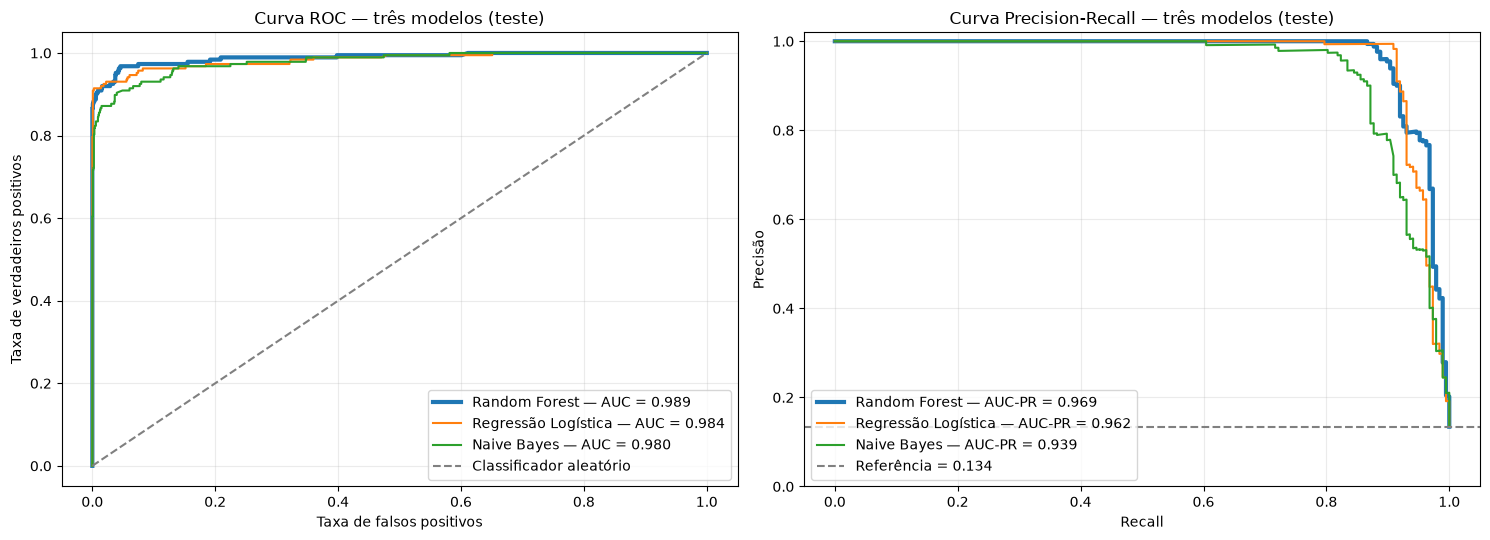

In [ ]:
# ---------------------------------------------------------
# Tabela comparativa: as mesmas métricas para os três modelos no teste
# (o enunciado pede tabelas comparativas para cada modelo)
# ---------------------------------------------------------

linhas_tabela = []
probabilidades_teste = {}

for nome, r in resultados.items():
    modelo = r["melhor_modelo"]
    prob = modelo.predict_proba(X_test)[:, list(modelo.classes_).index(1)]
    pred = (prob >= limiar).astype(int)
    prec_curva, rev_curva, _ = precision_recall_curve(y_test, prob, pos_label=1)
    probabilidades_teste[nome] = prob

    linhas_tabela.append({
        "Algoritmo": nome,
        "Melhor na validação": "sim" if nome == melhor_nome else "",
        "Acurácia": accuracy_score(y_test, pred),
        "Precisão": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "AUC-PR (trapezoidal)": auc(rev_curva, prec_curva),
        "Average Precision (AP)": average_precision_score(y_test, prob)
    })

tabela_teste = pd.DataFrame(linhas_tabela).set_index("Algoritmo")
display(tabela_teste.style.format(precision=4))

# Curvas ROC e PR dos três modelos no mesmo gráfico
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(15, 5.5))

for nome, prob in probabilidades_teste.items():
    espessura = 3 if nome == melhor_nome else 1.5
    fpr_m, tpr_m, _ = roc_curve(y_test, prob)
    ax_roc.plot(fpr_m, tpr_m, linewidth=espessura, label=f"{nome} — AUC = {tabela_teste.loc[nome, 'ROC-AUC']:.3f}")
    prec_m, rev_m, _ = precision_recall_curve(y_test, prob)
    ax_pr.plot(rev_m, prec_m, linewidth=espessura, label=f"{nome} — AUC-PR = {tabela_teste.loc[nome, 'AUC-PR (trapezoidal)']:.3f}")

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
ax_roc.set_title("Curva ROC — três modelos (teste)")
ax_roc.set_xlabel("Taxa de falsos positivos")
ax_roc.set_ylabel("Taxa de verdadeiros positivos")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.25)

ax_pr.axhline(proporcao_positiva, linestyle="--", color="gray", label=f"Referência = {proporcao_positiva:.3f}")
ax_pr.set_title("Curva Precision-Recall — três modelos (teste)")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precisão")
ax_pr.set_ylim(0, 1.02)
ax_pr.legend(loc="lower left")
ax_pr.grid(alpha=0.25)

plt.tight_layout()
plt.show()

> **Para o relatório:** comparar os modelos, apresentar o melhor com seus hiperparâmetros e desempenho no
> teste, e comentar os erros da matriz de confusão no contexto do domínio.

## 8. Programa da Parte 1 — histograma e faixas de decisão (reutilizável)
Função única que recebe apenas os **rótulos reais (0/1)** e as **probabilidades da classe positiva**. Por isso
funciona com qualquer base e qualquer modelo (Parte 1, itens i a iii).
- Eixo X: probabilidade de 0% a 100%. Eixo Y: % de instâncias em relação ao total do conjunto avaliado (item iv).
- `largura_intervalo` configura os intervalos; cada instância cai em exatamente um intervalo (item v).
- Azul: todas as instâncias. Vermelho: instâncias com rótulo real positivo, com os mesmos intervalos e o mesmo
  denominador (itens vi e vii).
- Faixas: negativa automática `p < t1`; análise manual `t1 ≤ p < t2`; positiva automática `p ≥ t2` (item viii).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def analisar_pontos_de_corte(y_real, y_prob, t1, t2, largura_intervalo=10,
                             nome_classe_positiva="positivo",
                             nomes_faixas=("Negativo automático", "Análise manual", "Positivo automático"),
                             titulo="Análise de pontos de corte"):
    # y_real: rótulo real de cada instância (0 ou 1)
    # y_prob: probabilidade estimada da classe positiva para TODAS as instâncias
    #         (não confundir com "instância cujo rótulo real é positivo")
    # t1, t2: pontos de corte entre 0 e 1, com t1 < t2
    # largura_intervalo: largura de cada intervalo do histograma, em pontos percentuais
    y_real = np.asarray(y_real).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    assert 0 <= t1 < t2 <= 1, "os cortes devem satisfazer 0 <= t1 < t2 <= 1"

    n_total = len(y_real)

    # Intervalos: 0-10, 10-20, ..., 90-100 (o último é fechado em 100%)
    bordas = np.append(np.arange(0, 100, largura_intervalo), 100)
    contagem_todas, _ = np.histogram(y_prob * 100, bins=bordas)
    contagem_positivas, _ = np.histogram(y_prob[y_real == 1] * 100, bins=bordas)
    assert contagem_todas.sum() == n_total   # cada instância em exatamente um intervalo

    # Mesmo denominador (total do conjunto avaliado) para as duas distribuições
    pct_todas = contagem_todas / n_total * 100
    pct_positivas = contagem_positivas / n_total * 100

    # ------------------------- gráfico -------------------------
    fig, ax = plt.subplots(figsize=(12, 6))
    larguras = np.diff(bordas)
    ax.bar(bordas[:-1], pct_todas, width=larguras, align="edge", color="royalblue",
           edgecolor="white", alpha=0.85, label="Todas as instâncias")
    ax.bar(bordas[:-1], pct_positivas, width=larguras, align="edge", color="red",
           edgecolor="white", alpha=0.75, label=f"Rótulo real positivo ({nome_classe_positiva})")

    ymax = max(pct_todas.max(), 1) * 1.25
    ax.axvline(t1 * 100, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(t2 * 100, color="black", linestyle="--", linewidth=1.5)
    ax.axvspan(0, t1 * 100, color="green", alpha=0.08, label=f"{nomes_faixas[0]}: p < {t1:.0%}")
    ax.axvspan(t1 * 100, t2 * 100, color="gold", alpha=0.15, label=f"{nomes_faixas[1]}: {t1:.0%} ≤ p < {t2:.0%}")
    ax.axvspan(t2 * 100, 100, color="red", alpha=0.07, label=f"{nomes_faixas[2]}: p ≥ {t2:.0%}")
    ax.text(t1 * 100 + 0.6, ymax * 0.98, f"t1 = {t1:.0%}", va="top", fontsize=9, fontweight="bold")
    ax.text(t2 * 100 + 0.6, ymax * 0.98, f"t2 = {t2:.0%}", va="top", fontsize=9, fontweight="bold")

    ax.set_xlim(0, 100)
    ax.set_ylim(0, ymax)
    ax.set_xticks(bordas)
    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel(f"% das instâncias do conjunto avaliado (n = {n_total})")
    ax.set_title(titulo)
    ax.legend(loc="best", fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    # ------------------------- tabelas -------------------------
    faixa_negativa = y_prob < t1
    faixa_manual = (y_prob >= t1) & (y_prob < t2)
    faixa_positiva = y_prob >= t2

    linhas = []
    for nome_faixa, mascara in zip(nomes_faixas, [faixa_negativa, faixa_manual, faixa_positiva]):
        n_faixa = int(mascara.sum())
        n_pos = int(y_real[mascara].sum())
        n_neg = n_faixa - n_pos
        linhas.append({
            "Faixa": nome_faixa,
            "Instâncias": n_faixa,
            "% da população": round(n_faixa / n_total * 100, 2),
            "Positivos reais": n_pos,
            "Negativos reais": n_neg,
            "% positivos na faixa": round(n_pos / n_faixa * 100, 2) if n_faixa else np.nan,
            "% negativos na faixa": round(n_neg / n_faixa * 100, 2) if n_faixa else np.nan,
        })
    tabela_faixas = pd.DataFrame(linhas)

    # Erros das decisões automáticas, com o denominador explícito
    total_positivos = int((y_real == 1).sum())
    total_negativos = int((y_real == 0).sum())
    positivos_na_faixa_negativa = int(y_real[faixa_negativa].sum())
    negativos_na_faixa_positiva = int((1 - y_real[faixa_positiva]).sum())

    tabela_erros = pd.DataFrame([
        {"Erro": "Positivos classificados automaticamente como negativos",
         "Numerador": positivos_na_faixa_negativa, "Denominador": total_positivos,
         "Denominador é": "total de positivos reais",
         "Proporção": round(positivos_na_faixa_negativa / total_positivos, 4) if total_positivos else np.nan},
        {"Erro": "Positivos classificados automaticamente como negativos",
         "Numerador": positivos_na_faixa_negativa, "Denominador": int(faixa_negativa.sum()),
         "Denominador é": f"total na faixa '{nomes_faixas[0]}'",
         "Proporção": round(positivos_na_faixa_negativa / faixa_negativa.sum(), 4) if faixa_negativa.sum() else np.nan},
        {"Erro": "Negativos classificados automaticamente como positivos",
         "Numerador": negativos_na_faixa_positiva, "Denominador": total_negativos,
         "Denominador é": "total de negativos reais",
         "Proporção": round(negativos_na_faixa_positiva / total_negativos, 4) if total_negativos else np.nan},
        {"Erro": "Negativos classificados automaticamente como positivos",
         "Numerador": negativos_na_faixa_positiva, "Denominador": int(faixa_positiva.sum()),
         "Denominador é": f"total na faixa '{nomes_faixas[2]}'",
         "Proporção": round(negativos_na_faixa_positiva / faixa_positiva.sum(), 4) if faixa_positiva.sum() else np.nan},
    ])

    return fig, tabela_faixas, tabela_erros


print("Função analisar_pontos_de_corte definida.")

Função analisar_pontos_de_corte definida.


## 9. Escolha dos pontos de corte na validação (item ix)
Os cortes precisam ser escolhidos com dados de **validação**. Como a validação deste notebook é cruzada, usamos
`cross_val_predict`: cada instância do treino recebe a probabilidade de um modelo que **não a viu** no
treinamento daquele fold (probabilidade out-of-fold). O teste não é usado aqui.

**Regra de escolha** (as tolerâncias estão no cartão da base):
- `t1` = maior limiar em que no máximo `tolerancia_t1` dos positivos reais ficam abaixo dele (faixa negativa automática).
- `t2` = menor limiar em que no máximo `tolerancia_t2` dos negativos reais ficam acima dele (faixa positiva automática).

Para fixar os cortes à mão, basta trocar `t1` e `t2` no final da célula.

Varredura de limiares na VALIDAÇÃO:


,limiar,% população abaixo,% dos positivos reais abaixo (erro se t1),% população acima,% dos negativos reais acima (erro se t2)
0,0.05,46.93,0.18,53.07,45.84
1,0.10,63.48,0.36,36.52,26.75
2,0.15,72.22,0.71,27.78,16.72
3,0.20,77.36,2.14,22.64,11.00
4,0.25,80.57,3.04,19.43,7.43
5,0.30,82.84,3.39,17.16,4.86
6,0.35,84.47,4.46,15.53,3.15
7,0.40,85.86,5.54,14.14,1.71
8,0.45,86.58,6.96,13.42,1.11
9,0.50,87.05,8.39,12.95,0.77



Pontos de corte escolhidos na validação: t1 = 0.23 | t2 = 0.54
(tolerâncias: até 3.0% dos positivos na faixa negativa automática, até 0.5% dos negativos na faixa positiva automática)


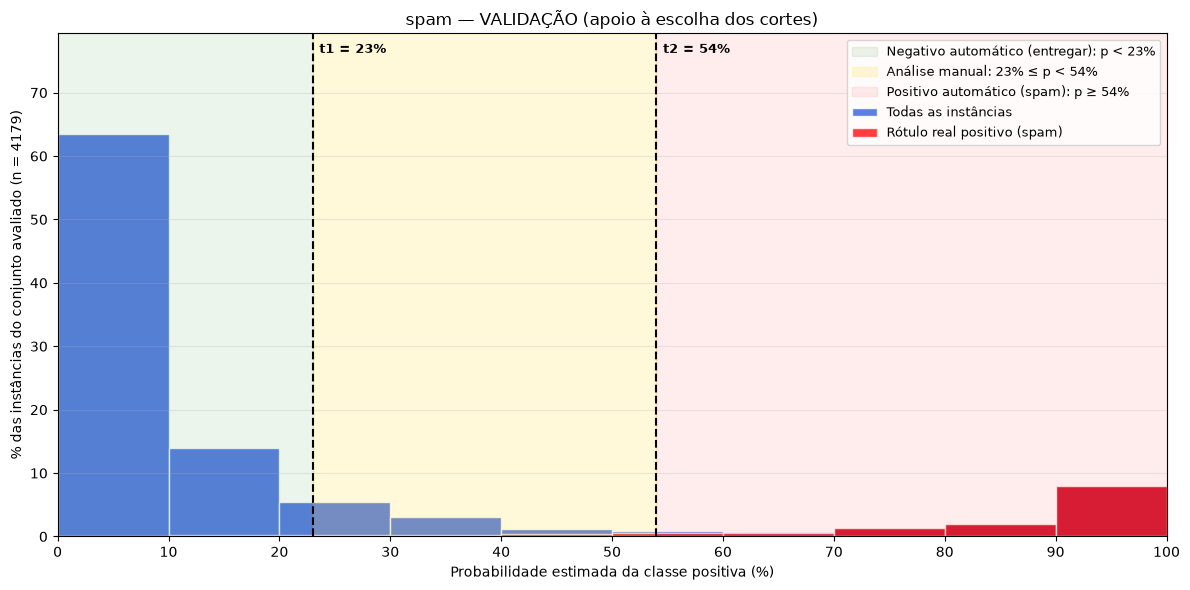

,Faixa,Instâncias,% da população,Positivos reais,Negativos reais,% positivos na faixa,% negativos na faixa
0,Negativo automático (entregar),3324,79.54,14,3310,0.42,99.58
1,Análise manual,333,7.97,42,291,12.61,87.39
2,Positivo automático (spam),522,12.49,504,18,96.55,3.45


In [ ]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

# Probabilidades out-of-fold do melhor modelo no TREINO (substituem o conjunto de validação)
prob_validacao = cross_val_predict(
    clone(melhor_modelo),
    X_train,
    y_train,
    cv=validacao,
    method="predict_proba",
    n_jobs=-1
)[:, list(melhor_modelo.classes_).index(1)]

y_validacao = np.asarray(y_train)
total_positivos_val = (y_validacao == 1).sum()
total_negativos_val = (y_validacao == 0).sum()

# Varredura de limiares: para cada limiar, quanto erro ele teria como t1 e como t2
linhas_varredura = []
for limiar_teste in np.round(np.arange(0.05, 1.0, 0.05), 2):
    abaixo = prob_validacao < limiar_teste
    acima = prob_validacao >= limiar_teste
    linhas_varredura.append({
        "limiar": limiar_teste,
        "% população abaixo": round(abaixo.mean() * 100, 2),
        "% dos positivos reais abaixo (erro se t1)": round((abaixo & (y_validacao == 1)).sum() / total_positivos_val * 100, 2),
        "% população acima": round(acima.mean() * 100, 2),
        "% dos negativos reais acima (erro se t2)": round((acima & (y_validacao == 0)).sum() / total_negativos_val * 100, 2),
    })
print("Varredura de limiares na VALIDAÇÃO:")
display(pd.DataFrame(linhas_varredura))

# Escolha automática pelas tolerâncias do cartão da base (grade de 0,01 em 0,01)
grade = np.round(np.arange(0.01, 1.0, 0.01), 2)
t1_candidatos = [t for t in grade
                 if ((prob_validacao < t) & (y_validacao == 1)).sum() / total_positivos_val <= config["tolerancia_t1"]]
t2_candidatos = [t for t in grade
                 if ((prob_validacao >= t) & (y_validacao == 0)).sum() / total_negativos_val <= config["tolerancia_t2"]]
t1 = max(t1_candidatos) if t1_candidatos else 0.01
t2 = min(t2_candidatos) if t2_candidatos else 0.99

# Se o modelo separa tão bem que as duas regras se cruzam, basta inverter
if t1 >= t2:
    t1, t2 = t2, t1
    if t1 == t2:
        t2 = round(t1 + 0.01, 2)

# Para fixar os cortes à mão, descomente e ajuste:
# t1, t2 = 0.35, 0.65

print(f"\nPontos de corte escolhidos na validação: t1 = {t1:.2f} | t2 = {t2:.2f}")
print(f"(tolerâncias: até {config['tolerancia_t1']:.1%} dos positivos na faixa negativa automática, "
      f"até {config['tolerancia_t2']:.1%} dos negativos na faixa positiva automática)")

fig, tabela_faixas_val, tabela_erros_val = analisar_pontos_de_corte(
    y_validacao, prob_validacao, t1, t2,
    largura_intervalo=10,
    nome_classe_positiva=str(classe_positiva),
    nomes_faixas=config["nomes_faixas"],
    titulo=f"{BASE_ESCOLHIDA} — VALIDAÇÃO (apoio à escolha dos cortes)"
)
plt.show()
display(tabela_faixas_val)

## 10. Aplicação dos cortes ao conjunto de teste (resultado final)
Os cortes escolhidos na validação são aplicados **sem nenhum ajuste** às probabilidades do teste do melhor modelo
(`y_prob`, calculado na seção 7).

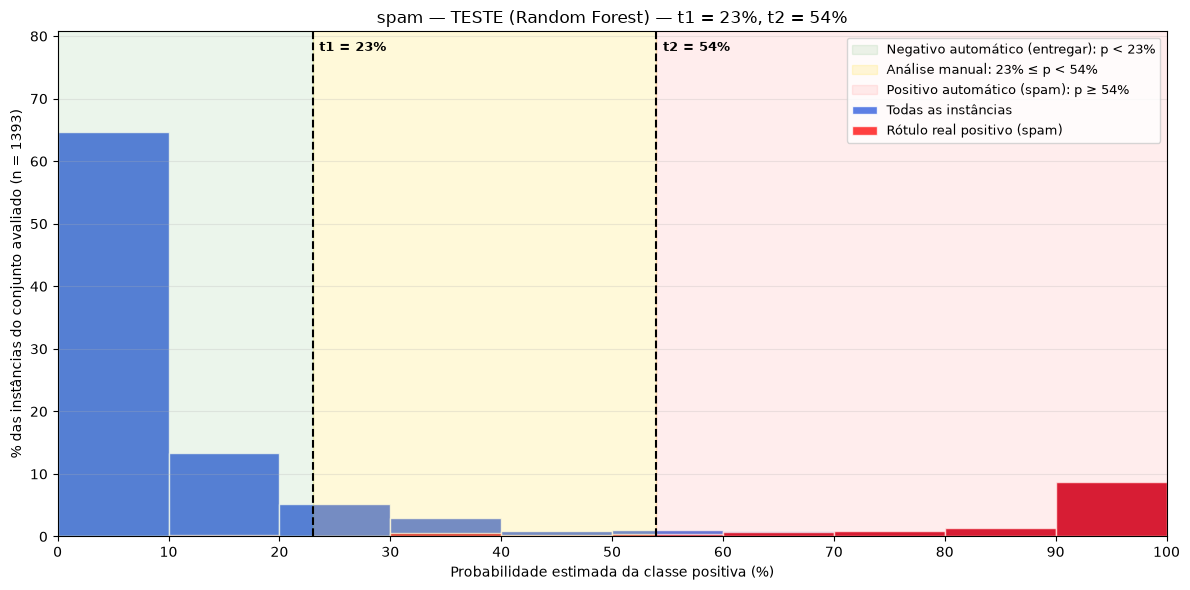

Percentual da população e composição de cada faixa (TESTE):


,Faixa,Instâncias,% da população,Positivos reais,Negativos reais,% positivos na faixa,% negativos na faixa
0,Negativo automático (entregar),1115,80.04,5,1110,0.45,99.55
1,Análise manual,106,7.61,16,90,15.09,84.91
2,Positivo automático (spam),172,12.35,166,6,96.51,3.49


Proporção de erro das decisões automáticas (denominador explícito):


,Erro,Numerador,Denominador,Denominador é,Proporção
0,Positivos classificados automaticamente como n...,5,187,total de positivos reais,0.0267
1,Positivos classificados automaticamente como n...,5,1115,total na faixa 'Negativo automático (entregar)',0.0045
2,Negativos classificados automaticamente como p...,6,1206,total de negativos reais,0.0050
3,Negativos classificados automaticamente como p...,6,172,total na faixa 'Positivo automático (spam)',0.0349


Cobertura automática: 92.39% | análise manual: 7.61%


In [ ]:
fig, tabela_faixas_teste, tabela_erros_teste = analisar_pontos_de_corte(
    y_test, y_prob, t1, t2,
    largura_intervalo=10,
    nome_classe_positiva=str(classe_positiva),
    nomes_faixas=config["nomes_faixas"],
    titulo=f"{BASE_ESCOLHIDA} — TESTE ({melhor_nome}) — t1 = {t1:.0%}, t2 = {t2:.0%}"
)
plt.show()

print("Percentual da população e composição de cada faixa (TESTE):")
display(tabela_faixas_teste)

print("Proporção de erro das decisões automáticas (denominador explícito):")
display(tabela_erros_teste)

cobertura_automatica = tabela_faixas_teste.loc[[0, 2], "% da população"].sum()
print(f"Cobertura automática: {cobertura_automatica:.2f}% | análise manual: {tabela_faixas_teste.loc[1, '% da população']:.2f}%")

> **Para o relatório:** apresentar t1 e t2 e justificar a política pela cobertura automática, pelos erros de
> cada faixa (com os denominadores) e pelo volume enviado à análise manual, considerando o domínio.